Entrenando modelo CvT en CIFAR-10...
[Epoch 1, Batch 100] Loss: 2.233
[Epoch 1, Batch 200] Loss: 1.953
[Epoch 1, Batch 300] Loss: 1.827
[Epoch 1] Train Loss: 1.966 | Val Loss: 1.676
[Epoch 2, Batch 100] Loss: 1.664
[Epoch 2, Batch 200] Loss: 1.571
[Epoch 2, Batch 300] Loss: 1.531
[Epoch 2] Train Loss: 1.575 | Val Loss: 1.426
[Epoch 3, Batch 100] Loss: 1.426
[Epoch 3, Batch 200] Loss: 1.425
[Epoch 3, Batch 300] Loss: 1.382
[Epoch 3] Train Loss: 1.399 | Val Loss: 1.376
[Epoch 4, Batch 100] Loss: 1.288
[Epoch 4, Batch 200] Loss: 1.264
[Epoch 4, Batch 300] Loss: 1.223
[Epoch 4] Train Loss: 1.242 | Val Loss: 1.243
[Epoch 5, Batch 100] Loss: 1.135
[Epoch 5, Batch 200] Loss: 1.113
[Epoch 5, Batch 300] Loss: 1.085
[Epoch 5] Train Loss: 1.105 | Val Loss: 1.142
[Epoch 6, Batch 100] Loss: 1.011
[Epoch 6, Batch 200] Loss: 1.015
[Epoch 6, Batch 300] Loss: 1.007
[Epoch 6] Train Loss: 1.003 | Val Loss: 1.014
[Epoch 7, Batch 100] Loss: 0.937
[Epoch 7, Batch 200] Loss: 0.941
[Epoch 7, Batch 300] Loss: 

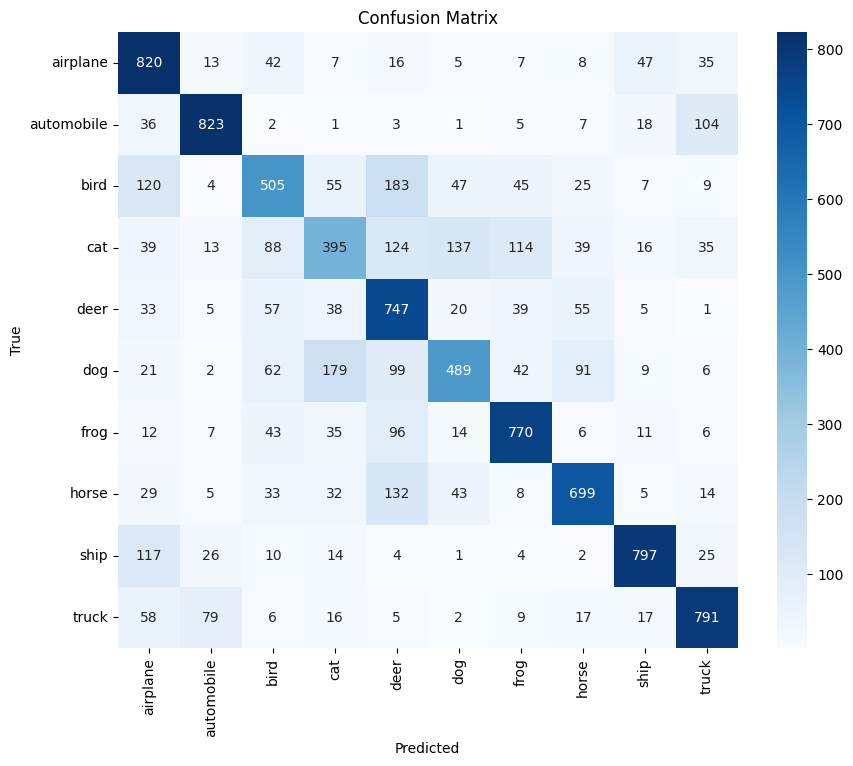


Classification Report:
              precision    recall  f1-score   support

    airplane       0.64      0.82      0.72      1000
  automobile       0.84      0.82      0.83      1000
        bird       0.60      0.51      0.55      1000
         cat       0.51      0.40      0.45      1000
        deer       0.53      0.75      0.62      1000
         dog       0.64      0.49      0.56      1000
        frog       0.74      0.77      0.75      1000
       horse       0.74      0.70      0.72      1000
        ship       0.86      0.80      0.83      1000
       truck       0.77      0.79      0.78      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



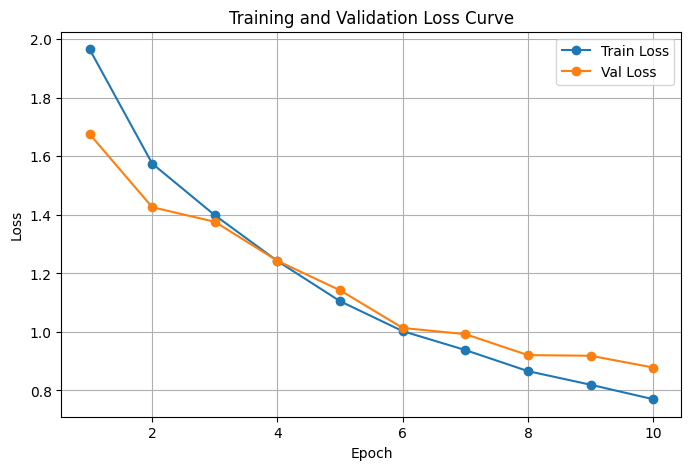

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Configuração de dispositivo (Define o dispositivo a ser usado para treinamento: GPU se disponível, caso contrário, CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convolutional Token Embedding (Camada para criar embeddings de token convolucionais)
class ConvTokenEmbedding(nn.Module):
    def __init__(self, in_channels, embed_dim, kernel_size=3, stride=2, padding=1):
        super().__init__()
        # Convolução para gerar tokens
        self.conv = nn.Conv2d(in_channels, embed_dim, kernel_size=kernel_size, stride=stride, padding=padding)
        # Normalização de camada
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Aplica a convolução
        x = self.conv(x)
        # Achata as dimensões espaciais e transpõe para [B, N, C] onde N é o número de tokens
        x = x.flatten(2).transpose(1, 2)
        # Aplica normalização
        x = self.norm(x)
        return x

# Convolutional Projection (Projeção convolucional usada na atenção)
class ConvolutionalProjection(nn.Module):
    def __init__(self, dim, kernel_size=3, stride=1, padding=None):
        super().__init__()
        # Define o padding padrão se não especificado
        if padding is None:
            padding = kernel_size // 2
        # Convolução de profundidade (depthwise convolution)
        self.depthwise = nn.Conv2d(dim, dim, kernel_size=kernel_size, stride=stride, padding=padding, groups=dim)
        # Normalização em lote
        self.bn = nn.BatchNorm2d(dim)
        # Convolução pontual (pointwise convolution)
        self.pointwise = nn.Conv2d(dim, dim, kernel_size=1)

    def forward(self, x):
        # Aplica convolução de profundidade
        x = self.depthwise(x)
        # Aplica normalização em lote
        x = self.bn(x)
        # Aplica convolução pontual
        x = self.pointwise(x)
        return x

# Multi-Head Attention with Convolutional Projection (Mecanismo de atenção multi-cabeça com projeção convolucional)
class MultiHeadAttention(nn.Module):
    def __init__(self, dim, num_heads, kernel_size=3, stride_kv=1, with_cls_token=False, att_drop=0., proj_drop=0.):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        # Fator de escala para a atenção
        self.scale = (dim // num_heads) ** -0.5
        self.with_cls_token = with_cls_token
        # Projeções Q, K, V usando ConvolutionalProjection
        self.q_proj = ConvolutionalProjection(dim, kernel_size, stride=1)
        self.k_proj = ConvolutionalProjection(dim, kernel_size, stride=stride_kv)
        self.v_proj = ConvolutionalProjection(dim, kernel_size, stride=stride_kv)
        # Dropout para a atenção
        self.attn_drop = nn.Dropout(att_drop)
        # Projeção de saída
        self.proj = nn.Linear(dim, dim)
        # Dropout para a projeção de saída
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, H, W):
        B, N, C = x.shape
        # Separa o token de classificação (CLS) se presente
        if self.with_cls_token:
            cls_token, x = x[:, :1, :], x[:, 1:, :]
            N_patch = N - 1
        else:
            N_patch = N
            cls_token = None
        # Remodela para 2D para aplicar as convoluções
        x_patch = x.reshape(B, H, W, C).permute(0, 3, 1, 2)
        # Aplica as projeções Q, K, V
        q = self.q_proj(x_patch).permute(0, 2, 3, 1).flatten(1, 2)
        k = self.k_proj(x_patch).permute(0, 2, 3, 1).flatten(1, 2)
        v = self.v_proj(x_patch).permute(0, 2, 3, 1).flatten(1, 2)
        # Concatena o token CLS de volta se presente
        if self.with_cls_token:
            q = torch.cat((cls_token, q), dim=1)
            k = torch.cat((cls_token, k), dim=1)
            v = torch.cat((cls_token, v), dim=1)
        # Divide as cabeças de atenção
        q = q.reshape(B, q.shape[1], self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        k = k.reshape(B, k.shape[1], self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        v = v.reshape(B, v.shape[1], self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        # Calcula a atenção
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        # Aplica a atenção aos valores
        x = attn @ v
        # Combina as cabeças e remodela para a forma original
        x = x.transpose(1, 2).reshape(B, N, C) # Remodelagem corrigida
        # Aplica a projeção de saída
        x = self.proj(x)
        # Aplica dropout
        x = self.proj_drop(x)
        return x

# MLP (Multi-Layer Perceptron)
class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4, drop=0.):
        super().__init__()
        # Primeira camada linear
        self.fc1 = nn.Linear(dim, int(dim * mlp_ratio))
        # Função de ativação GELU
        self.act = nn.GELU()
        # Segunda camada linear
        self.fc2 = nn.Linear(int(dim * mlp_ratio), dim)
        # Dropout
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        # Aplica as camadas lineares e ativação com dropout
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

# Convolutional Transformer Block (Bloco básico do CvT)
class ConvTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, kernel_size=3, mlp_ratio=4, drop=0., attn_drop=0., drop_path=0., with_cls_token=False, stride_kv=1):
        super().__init__()
        # Primeira normalização de camada
        self.norm1 = nn.LayerNorm(dim)
        # Mecanismo de atenção multi-cabeça com projeção convolucional
        self.attn = MultiHeadAttention(dim, num_heads, kernel_size, stride_kv=stride_kv, with_cls_token=with_cls_token, att_drop=attn_drop, proj_drop=drop)
        # Segunda normalização de camada
        self.norm2 = nn.LayerNorm(dim)
        # MLP
        self.mlp = MLP(dim, mlp_ratio, drop=drop)
        # DropPath (identidade se não implementado)
        self.drop_path = nn.Identity()  # Poderia usar DropPath se implementado

    def forward(self, x, H, W):
        # Aplica atenção com conexão residual
        x = x + self.drop_path(self.attn(self.norm1(x), H, W))
        # Aplica MLP com conexão residual
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

# CvT Model (Modelo Convolutional Vision Transformer)
class CvT(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Stage 1 (Primeira etapa: token embedding e blocos transformer)
        self.stage1_embed = ConvTokenEmbedding(3, 64, kernel_size=3, stride=2, padding=1)
        self.stage1_blocks = nn.ModuleList([ConvTransformerBlock(64, 1, kernel_size=3, with_cls_token=False) for _ in range(1)])
        # Stage 2 (Segunda etapa: token embedding e blocos transformer)
        self.stage2_embed = ConvTokenEmbedding(64, 192, kernel_size=3, stride=2, padding=1)
        self.stage2_blocks = nn.ModuleList([ConvTransformerBlock(192, 3, kernel_size=3, with_cls_token=False) for _ in range(2)])
        # Stage 3 (Terceira etapa: token embedding, token CLS e blocos transformer)
        self.stage3_embed = ConvTokenEmbedding(192, 384, kernel_size=3, stride=2, padding=1)
        # Token de classificação (CLS)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 384))
        self.stage3_blocks = nn.ModuleList([ConvTransformerBlock(384, 6, kernel_size=3, with_cls_token=True) for _ in range(10)])
        # Normalização final
        self.norm = nn.LayerNorm(384)
        # Camada de classificação (cabeça)
        self.head = nn.Linear(384, num_classes)

    def forward(self, x):
        # Stage 1 (Passa a entrada pela primeira etapa)
        x = self.stage1_embed(x)  # B, 3,32,32 -> B,16*16,64
        B, N, C = x.shape
        H, W = int(N**0.5), int(N**0.5)
        for blk in self.stage1_blocks:
            x = blk(x, H, W)
        # Remodela para a forma de imagem para a próxima etapa convolucional
        x = x.reshape(B, H, W, C).permute(0, 3, 1, 2)
        # Stage 2 (Passa a saída da primeira etapa pela segunda etapa)
        x = self.stage2_embed(x)  # B,8*8,192
        B, N, C = x.shape
        H, W = int(N**0.5), int(N**0.5)
        for blk in self.stage2_blocks:
            x = blk(x, H, W)
        # Remodela para a forma de imagem para a próxima etapa convolucional
        x = x.reshape(B, H, W, C).permute(0, 3, 1, 2)
        # Stage 3 (Passa a saída da segunda etapa pela terceira etapa)
        x = self.stage3_embed(x)  # B,4*4,384
        B, N, C = x.shape
        H, W = int(N**0.5), int(N**0.5)
        # Repete o token CLS para o tamanho do batch
        cls_token = self.cls_token.repeat(B, 1, 1)
        # Concatena o token CLS com os tokens de imagem
        x = torch.cat((cls_token, x), dim=1)
        # Passa pelos blocos transformer da terceira etapa
        for blk in self.stage3_blocks:
            x = blk(x, H, W)
        # Normaliza e seleciona o token CLS para classificação
        x = self.norm(x[:, 0, :])
        # Passa pela camada de classificação
        x = self.head(x)
        return x

# Cargar CIFAR-10 (Carrega o dataset CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(), # Converte a imagem para tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normaliza os canais
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split train into train and val (Divide o conjunto de treinamento em treino e validação)
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(trainset, [train_size, val_size])

# Cria DataLoaders para carregar os dados em batches
trainloader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
valloader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# Inicializar modelo, perda e otimizador (Inicializa o modelo, a função de perda e o otimizador)
model = CvT(num_classes=10).to(device) # Instancia o modelo e move para o dispositivo
criterion = nn.CrossEntropyLoss() # Define a função de perda de entropia cruzada
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05) # Define o otimizador AdamW

# Entrenamiento con registro de pérdida (Função para treinar o modelo)
def train(model, trainloader, valloader, criterion, optimizer, epochs=10):
    losses = [] # Lista para armazenar as perdas de treinamento
    val_losses = [] # Lista para armazenar as perdas de validação
    for epoch in range(epochs):
        model.train() # Define o modelo para o modo de treinamento
        running_loss = 0.0 # Perda acumulada para impressão periódica
        epoch_loss = 0.0 # Perda total da época
        batch_count = 0 # Contador de batches
        for i, (inputs, labels) in enumerate(trainloader):
            inputs, labels = inputs.to(device), labels.to(device) # Move dados para o dispositivo
            optimizer.zero_grad() # Zera os gradientes do otimizador
            outputs = model(inputs) # Executa o forward pass
            loss = criterion(outputs, labels) # Calcula a perda
            loss.backward() # Calcula os gradientes (backward pass)
            optimizer.step() # Atualiza os pesos do modelo
            running_loss += loss.item() # Acumula a perda para impressão
            epoch_loss += loss.item() # Acumula a perda da época
            batch_count += 1 # Incrementa o contador de batches
            if i % 100 == 99: # Imprime a perda média a cada 100 batches
                print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 100:.3f}')
                running_loss = 0.0
        losses.append(epoch_loss / batch_count) # Armazena a perda média da época de treino
        # Validation loss (Calcula a perda de validação)
        model.eval() # Define o modelo para o modo de avaliação
        val_loss = 0.0 # Perda de validação acumulada
        val_batch = 0 # Contador de batches de validação
        with torch.no_grad(): # Desabilita o cálculo de gradientes
            for inputs, labels in valloader:
                inputs, labels = inputs.to(device), labels.to(device) # Move dados para o dispositivo
                outputs = model(inputs) # Executa o forward pass
                loss = criterion(outputs, labels) # Calcula a perda
                val_loss += loss.item() # Acumula a perda de validação
                val_batch += 1 # Incrementa o contador de batches de validação
        val_losses.append(val_loss / val_batch) # Armazena a perda média da época de validação
        print(f'[Epoch {epoch + 1}] Train Loss: {losses[-1]:.3f} | Val Loss: {val_losses[-1]:.3f}') # Imprime as perdas de treino e validação
        model.train() # Retorna o modelo para o modo de treinamento
    return losses, val_losses # Retorna as listas de perdas

# Evaluación con matriz de confusión y métricas (Função para avaliar o modelo no conjunto de teste)
def evaluate(model, testloader):
    model.eval() # Define o modelo para o modo de avaliação
    correct = 0 # Contador de previsões corretas
    total = 0 # Contador total de amostras
    all_preds = [] # Lista para armazenar todas as previsões
    all_labels = [] # Lista para armazenar todos os rótulos verdadeiros
    with torch.no_grad(): # Desabilita o cálculo de gradientes
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device) # Move dados para o dispositivo
            outputs = model(inputs) # Executa o forward pass
            _, predicted = torch.max(outputs.data, 1) # Obtém a classe prevista
            total += labels.size(0) # Atualiza o contador total
            correct += (predicted == labels).sum().item() # Atualiza o contador de corretas
            all_preds.extend(predicted.cpu().numpy()) # Armazena as previsões
            all_labels.extend(labels.cpu().numpy()) # Armazena os rótulos verdadeiros

    accuracy = 100 * correct / total # Calcula a acurácia
    print(f'Accuracy on test set: {accuracy:.2f}%') # Imprime a acurácia

    # Matriz de confusión (Calcula e exibe a matriz de confusão)
    cm = confusion_matrix(all_labels, all_preds)
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck'] # Nomes das classes
    plt.figure(figsize=(10, 8)) # Cria uma figura para a matriz de confusão
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names) # Cria o heatmap
    plt.xlabel('Predicted') # Rótulo do eixo X
    plt.ylabel('True') # Rótulo do eixo Y
    plt.title('Confusion Matrix') # Título do gráfico
    plt.show() # Exibe o gráfico

    # Reporte de clasificación (Exibe o relatório de classificação)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return accuracy, cm # Retorna a acurácia e a matriz de confusão

# Ejecutar entrenamiento y evaluación (Executa o treinamento e a avaliação)
print("Entrenando modelo CvT en CIFAR-10...") # Mensagem de início do treinamento
losses, val_losses = train(model, trainloader, valloader, criterion, optimizer, epochs=10) # Chama a função de treinamento
print("\nEvaluando modelo...") # Mensagem de início da avaliação
accuracy, cm = evaluate(model, testloader) # Chama a função de avaliação

# Graficar curva de pérdida train y val (Plota as curvas de perda de treinamento e validação)
plt.figure(figsize=(8, 5)) # Cria uma figura para o gráfico
plt.plot(range(1, len(losses) + 1), losses, marker='o', label='Train Loss') # Plota a perda de treino
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Val Loss') # Plota a perda de validação
plt.xlabel('Epoch') # Rótulo do eixo X
plt.ylabel('Loss') # Rótulo do eixo Y
plt.title('Training and Validation Loss Curve') # Título do gráfico
plt.legend() # Exibe a legenda
plt.grid(True) # Adiciona grade ao gráfico
plt.show() # Exibe o gráfico